In [1]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)


3.0.2
2.4.4


In [2]:
data = pd.Series(np.random.randn(9),index=[['a', 'a', 'a', 'b', 'b', 'c', 'c', 'd', 'd'],[1, 2, 3, 1, 3, 1, 2, 2, 3]])
data.index

MultiIndex([('a', 1),
            ('a', 2),
            ('a', 3),
            ('b', 1),
            ('b', 3),
            ('c', 1),
            ('c', 2),
            ('d', 2),
            ('d', 3)],
           )

# 随机过程（Random Process）模拟

本节演示几种常见的随机过程模拟，包括：
1. **布朗运动（Brownian Motion / Wiener Process）**
2. **几何布朗运动（Geometric Brownian Motion）**
3. **泊松过程（Poisson Process）**

In [3]:
# ==========================================
# 1. 布朗运动（Brownian Motion / Wiener Process）
# ==========================================

np.random.seed(42)

# 参数设置
T = 1.0          # 总时间
N = 1000         # 时间步数
dt = T / N       # 时间步长
n_paths = 5      # 模拟路径数

# 生成时间轴
t = np.linspace(0, T, N+1)

# 模拟布朗运动：W(t) = sum(dW), 其中 dW ~ N(0, dt)
dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
W = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(dW, axis=1)], axis=1)

# 转换为 DataFrame
bm_df = pd.DataFrame(W.T, index=t, columns=[f'Path {i+1}' for i in range(n_paths)])
bm_df.index.name = 'Time'

print("布朗运动模拟结果（前5行）：")
print(bm_df.head())
print(f"\n形状: {bm_df.shape}")

布朗运动模拟结果（前5行）：
         Path 1    Path 2    Path 3    Path 4    Path 5
Time                                                   
0.000  0.000000  0.000000  0.000000  0.000000  0.000000
0.001  0.015707  0.044252 -0.021351 -0.060330 -0.027306
0.002  0.011335  0.073491 -0.025921 -0.087538 -0.028293
0.003  0.031817  0.075377 -0.050980 -0.100617 -0.027723
0.004  0.079979  0.054919 -0.060718 -0.040923 -0.012777

形状: (1001, 5)


In [4]:
# ==========================================
# 2. 几何布朗运动（Geometric Brownian Motion）
# ==========================================
# 常用于股票价格建模: dS = mu*S*dt + sigma*S*dW

np.random.seed(123)

# 参数设置
S0 = 100         # 初始价格
mu = 0.05        # 漂移率（年化收益率）
sigma = 0.2      # 波动率
T = 1.0          # 时间（1年）
N = 252          # 交易日数量
dt = T / N       # 每日时间步长
n_paths = 5      # 模拟路径数

# 生成时间轴
t = np.linspace(0, T, N+1)

# 模拟几何布朗运动
dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))

# 使用解析解: S(t) = S0 * exp((mu - 0.5*sigma^2)*t + sigma*W(t))
W = np.cumsum(dW, axis=1)
exponent = (mu - 0.5 * sigma**2) * dt * np.arange(1, N+1) + sigma * W
S = S0 * np.exp(exponent)
S = np.concatenate([np.full((n_paths, 1), S0), S], axis=1)

# 转换为 DataFrame
gbm_df = pd.DataFrame(S.T, index=t, columns=[f'Stock {i+1}' for i in range(n_paths)])
gbm_df.index.name = 'Time (Years)'

print("几何布朗运动模拟结果（股票价格，前5行）：")
print(gbm_df.head())
print(f"\n最终价格统计：")
print(gbm_df.iloc[-1].describe())

几何布朗运动模拟结果（股票价格，前5行）：
                 Stock 1     Stock 2     Stock 3     Stock 4     Stock 5
Time (Years)                                                            
0.000000      100.000000  100.000000  100.000000  100.000000  100.000000
0.003968       98.653289   99.155682  101.613265   99.861421   98.999340
0.007937       99.912619   97.075823  103.352293  101.110152   97.432045
0.011905      100.281400   98.000087  102.083002  100.165872   98.125694
0.015873       98.407966   97.912298  101.410017   98.597881   98.824590

最终价格统计：
count      5.000000
mean      98.204138
std       30.316471
min       56.385762
25%       84.893588
50%       99.905739
75%      112.263323
max      137.572277
Name: 1.0, dtype: float64


# 可视化随机过程：一维随机游走

随机游走是一种简单直观的随机过程：每一步都有一定概率向上或向下移动。
下面模拟多条随机游走路径，并观察路径均值和最终位置的分布。


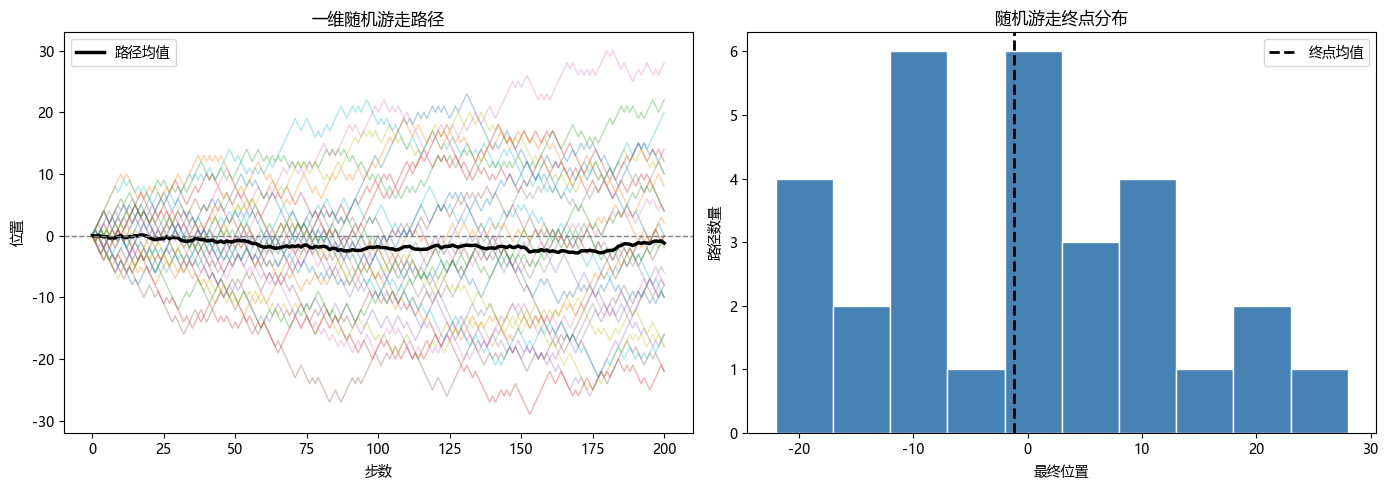

In [5]:
import matplotlib.pyplot as plt

# 设置中文字体，避免 Matplotlib 默认字体无法显示中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 固定随机种子，保证每次运行得到相同结果
np.random.seed(42)

# 参数设置
n_steps = 200
n_paths = 30

# 每一步随机向上(+1)或向下(-1)移动
steps = np.random.choice([-1, 1], size=(n_paths, n_steps))

# 对步长累加得到路径，并在开头补上初始位置0
paths = np.cumsum(steps, axis=1)
paths = np.column_stack([np.zeros(n_paths), paths])
time = np.arange(n_steps + 1)

# 可视化随机游走路径和终点分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for path in paths:
    axes[0].plot(time, path, alpha=0.35, linewidth=1)

mean_path = paths.mean(axis=0)
axes[0].plot(time, mean_path, color='black', linewidth=2.5, label='路径均值')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('一维随机游走路径')
axes[0].set_xlabel('步数')
axes[0].set_ylabel('位置')
axes[0].legend()

final_positions = paths[:, -1]
axes[1].hist(final_positions, bins=10, color='steelblue', edgecolor='white')
axes[1].axvline(final_positions.mean(), color='black', linestyle='--', linewidth=2, label='终点均值')
axes[1].set_title('随机游走终点分布')
axes[1].set_xlabel('最终位置')
axes[1].set_ylabel('路径数量')
axes[1].legend()

plt.tight_layout()
plt.show()


# 可视化随机过程：二维随机游走

二维随机游走允许粒子在平面中自由移动，每一步在随机方向上移动单位长度。
这种模型常用于描述布朗运动在二维空间中的扩散行为。


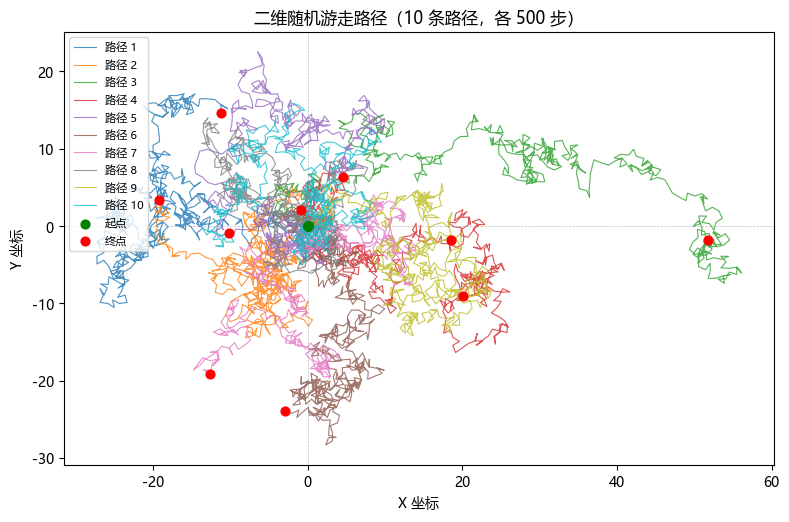

In [6]:
# ==========================================
# 二维随机游走（2D Random Walk）
# ==========================================

np.random.seed(123)

n_steps = 500
n_paths = 10

# 每一步随机选择角度，再分解为 x 和 y 方向上的位移
angles = np.random.uniform(0, 2 * np.pi, size=(n_paths, n_steps))
dx = np.cos(angles)
dy = np.sin(angles)

# 对位移累加得到路径坐标，并在开头补上原点
x = np.cumsum(dx, axis=1)
y = np.cumsum(dy, axis=1)
x = np.column_stack([np.zeros(n_paths), x])
y = np.column_stack([np.zeros(n_paths), y])

# 绘图
fig, ax = plt.subplots(figsize=(8, 8))

# 使用渐变色绘制每条路径
colors = plt.cm.tab10(np.linspace(0, 1, n_paths))

for i in range(n_paths):
    ax.plot(x[i], y[i], linewidth=0.8, alpha=0.8, color=colors[i],
            label=f'路径 {i+1}')
    # 标记起点（绿色圆点）
    ax.scatter(x[i, 0], y[i, 0], color='green', s=40, zorder=5)
    # 标记终点（红色圆点）
    ax.scatter(x[i, -1], y[i, -1], color='red', s=40, zorder=5)

# 只对一个起点和终点添加图例说明
ax.scatter([], [], color='green', s=40, label='起点')
ax.scatter([], [], color='red', s=40, label='终点')

ax.set_title('二维随机游走路径（10 条路径，各 500 步）')
ax.set_xlabel('X 坐标')
ax.set_ylabel('Y 坐标')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.legend(loc='upper left', fontsize=8)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()


# Ornstein-Uhlenbeck Process (Mean-Reverting)

The Ornstein-Uhlenbeck (OU) process is a mean-reverting stochastic process.
Unlike Brownian motion which drifts freely, the OU process is pulled back toward
a long-term mean $\mu$ with strength $\theta$ (rate of reversion).

$$dX_t = \theta(\mu - X_t)dt + \sigma dW_t$$

Widely used in:
- **Finance**: Vasicek model for interest rates
- **Physics**: Velocity of a Brownian particle (original Ornstein-Uhlenbeck paper)
- **Neuroscience**: Membrane potential models


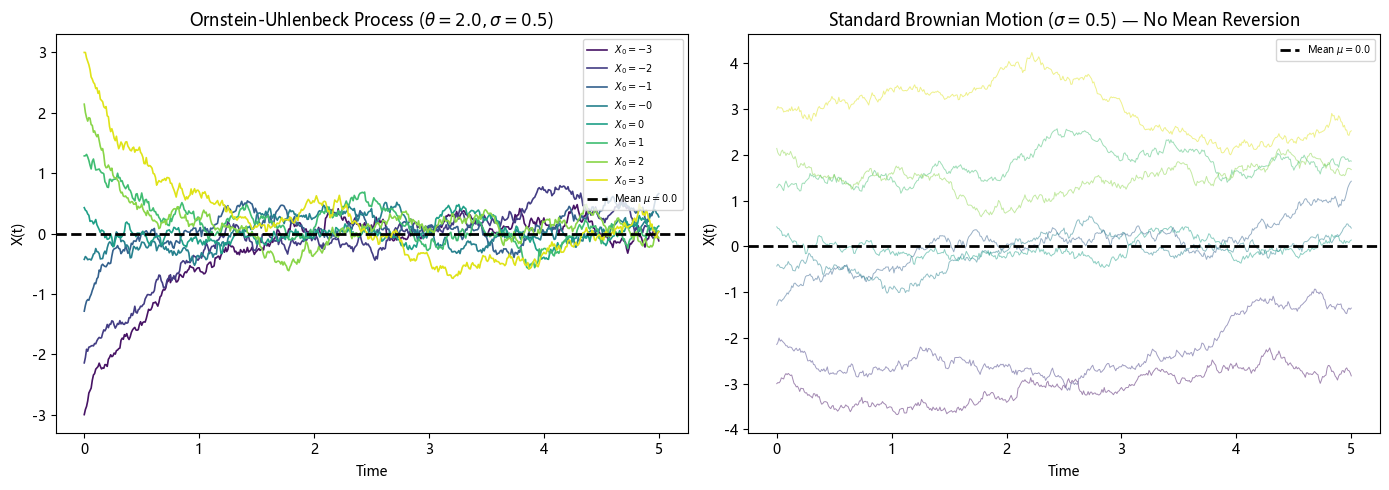

In [7]:
# ==========================================
# Ornstein-Uhlenbeck (Mean-Reverting) Process
# ==========================================
# dX = theta * (mu - X) * dt + sigma * dW

np.random.seed(42)

# Parameters
mu = 0.0         # long-term mean
theta = 2.0      # speed of reversion (higher = faster pull-back)
sigma = 0.5      # volatility
T = 5.0          # total time
N = 500          # time steps
dt = T / N
n_paths = 8

# Different starting values spread around the mean
x0_values = np.linspace(-3, 3, n_paths)
t = np.linspace(0, T, N + 1)

# Euler-Maruyama discretization
X = np.zeros((n_paths, N + 1))
X[:, 0] = x0_values

dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))

for i in range(N):
    X[:, i + 1] = X[:, i] + theta * (mu - X[:, i]) * dt + sigma * dW[:, i]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.viridis(np.linspace(0.05, 0.95, n_paths))

for i in range(n_paths):
    axes[0].plot(t, X[i], linewidth=1.2, color=colors[i],
                 label=f'$X_0 = {x0_values[i]:.0f}$')

axes[0].axhline(mu, color='black', linestyle='--', linewidth=2, label=f'Mean $\\mu = {mu}$')
axes[0].set_title(f'Ornstein-Uhlenbeck Process ($\\theta={theta}, \\sigma={sigma}$)')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('X(t)')
axes[0].legend(fontsize=7, loc='upper right')

# Compare: OU vs standard Brownian motion (no mean reversion)
np.random.seed(42)  # same seed for fair comparison
B = np.zeros((n_paths, N + 1))
B[:, 0] = x0_values
dW2 = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
for i in range(N):
    B[:, i + 1] = B[:, i] + sigma * dW2[:, i]

for i in range(n_paths):
    axes[1].plot(t, B[i], linewidth=0.7, alpha=0.5, color=colors[i])

axes[1].axhline(mu, color='black', linestyle='--', linewidth=2, label=f'Mean $\\mu = {mu}$')
axes[1].set_title(f'Standard Brownian Motion ($\\sigma={sigma}$) — No Mean Reversion')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('X(t)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()


# 复杂模拟数据：多元回归分析

下面构造一个更接近真实业务场景的模拟数据集：包含连续变量、分类变量、非线性项、交互项、异方差噪声和少量缺失值。
然后使用 `statsmodels` 拟合 OLS 回归模型，并输出完整回归结果、系数表和预测效果指标。


数据维度: (1200, 9)
缺失值数量:
sales                0
price               21
competitor_price     0
ad_spend            27
customer_age         0
loyalty_score       35
seasonality          0
region               0
channel              0
dtype: int64


,sales,price,competitor_price,ad_spend,customer_age,loyalty_score,seasonality,region,channel
0,209.326044,45.285730,52.063632,86.103272,31.844931,27.840393,0.000000,华东,线上
1,153.234462,89.534472,82.020692,57.753150,23.692532,21.065443,0.015720,华南,线下
2,195.993426,NaN,112.005192,58.123545,42.255090,49.710615,0.031437,华北,混合
3,191.460711,83.792688,97.474998,38.461730,22.389206,56.972405,0.047146,华北,线下
4,286.797820,59.057815,61.736875,184.937283,44.110616,42.746188,0.062843,华北,线上



OLS 回归结果（使用 HC3 稳健标准误）
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     406.9
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:17:50   Log-Likelihood:                -5496.9
No. Observations:                1200   AIC:                         1.103e+04
Df Residuals:                    1180   BIC:                         1.114e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------

,coef,std_err,t_value,p_value,ci_low,ci_high
Intercept,144.784409,5.214461,27.765939,1.118865e-169,134.564253,155.004565
ad_spend:loyalty_score,0.017661,0.000831,21.241222,3.974124e-100,0.016032,0.019291
I(ad_spend ** 2),-0.002473,0.000146,-16.990573,9.644165e-65,-0.002758,-0.002188
ad_spend,0.570194,0.046739,12.199436,3.129835e-34,0.478587,0.661802
seasonality,11.944510,0.992781,12.031364,2.431120e-33,9.998695,13.890325
loyalty_score,0.723889,0.073670,9.826115,8.690709e-23,0.579499,0.868279
C(channel)[T.线上],25.620894,3.077296,8.325783,8.377343e-17,19.589505,31.652282
price,-0.861587,0.128302,-6.715290,1.876923e-11,-1.113054,-0.610119
customer_age,0.413585,0.068915,6.001389,1.956365e-09,0.278514,0.548655
C(region)[T.华南]:C(channel)[T.线上],-20.590735,4.876935,-4.222065,2.420748e-05,-30.149352,-11.032118



模型拟合指标：
R^2  : 0.8733
RMSE : 23.61
MAE  : 18.20


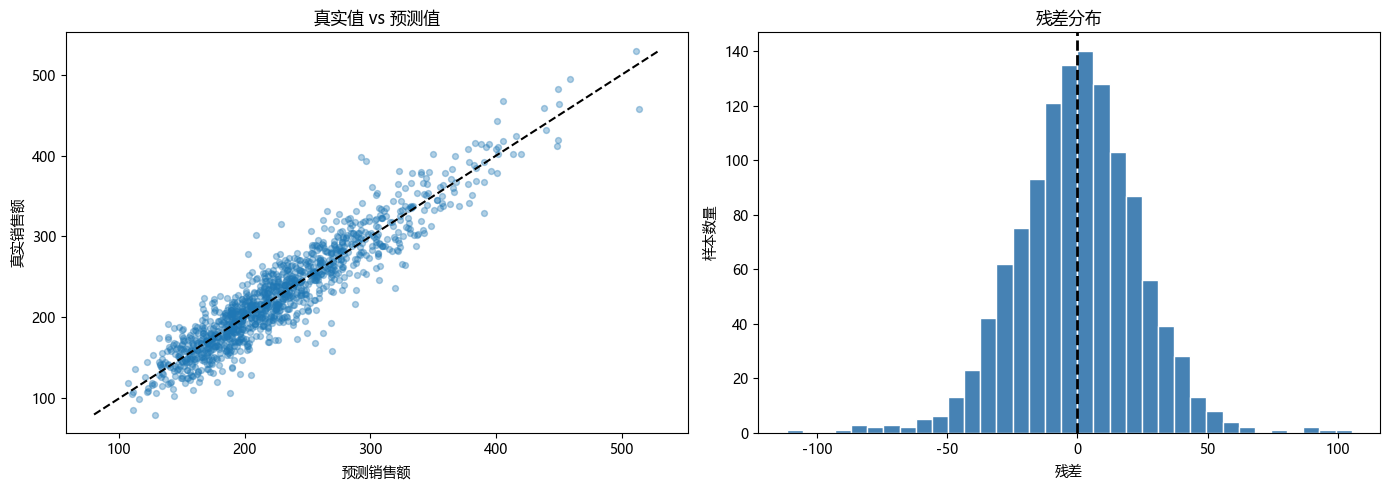

In [8]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 设置中文字体，避免 Matplotlib 默认字体无法显示中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 1. 构造复杂模拟数据
rng = np.random.default_rng(2026)
n = 1_200

region = rng.choice(['华东', '华北', '华南', '西部'], size=n, p=[0.34, 0.26, 0.24, 0.16])
channel = rng.choice(['线上', '线下', '混合'], size=n, p=[0.45, 0.35, 0.20])
price = rng.lognormal(mean=4.15, sigma=0.32, size=n)
ad_spend = rng.gamma(shape=2.4, scale=38, size=n)
customer_age = np.clip(rng.normal(loc=36, scale=10, size=n), 18, 70)
loyalty_score = rng.beta(a=2.2, b=4.0, size=n) * 100
competitor_price = price * rng.normal(loc=1.04, scale=0.10, size=n)
seasonality = np.sin(np.linspace(0, 6 * np.pi, n))

region_effect = {'华东': 18, '华北': 5, '华南': 11, '西部': -7}
channel_effect = {'线上': 16, '线下': -4, '混合': 9}
noise_scale = 14 + 0.08 * ad_spend
noise = rng.normal(loc=0, scale=noise_scale, size=n)

# 真实数据生成过程：线性项 + 非线性项 + 交互项 + 类别效应 + 异方差噪声
sales = (
    120
    - 1.35 * price
    + 0.82 * competitor_price
    + 0.58 * ad_spend
    - 0.0026 * ad_spend**2
    + 0.72 * loyalty_score
    + 0.45 * customer_age
    + 0.018 * ad_spend * loyalty_score
    + 12 * seasonality
    + np.array([region_effect[x] for x in region])
    + np.array([channel_effect[x] for x in channel])
    + np.where((region == '华东') & (channel == '线上'), 14, 0)
    + noise
)

reg_df = pd.DataFrame({
    'sales': sales,
    'price': price,
    'competitor_price': competitor_price,
    'ad_spend': ad_spend,
    'customer_age': customer_age,
    'loyalty_score': loyalty_score,
    'seasonality': seasonality,
    'region': region,
    'channel': channel,
})

# 人为加入少量缺失值，模拟真实数据清洗场景
for col in ['price', 'ad_spend', 'loyalty_score']:
    missing_mask = rng.random(n) < 0.025
    reg_df.loc[missing_mask, col] = np.nan

print("数据维度:", reg_df.shape)
print("缺失值数量:")
print(reg_df.isna().sum())
display(reg_df.head())

# 2. 缺失值处理：数值变量用中位数填补
model_df = reg_df.copy()
numeric_cols = ['price', 'competitor_price', 'ad_spend', 'customer_age', 'loyalty_score', 'seasonality']
for col in numeric_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# 3. 拟合包含非线性项、交互项和类别变量的 OLS 模型
formula = (
    'sales ~ price + competitor_price + ad_spend + I(ad_spend ** 2) '
    '+ customer_age + loyalty_score + ad_spend:loyalty_score '
    '+ seasonality + C(region) + C(channel) + C(region):C(channel)'
)

ols_model = smf.ols(formula=formula, data=model_df).fit(cov_type="HC3")

print("\nOLS 回归结果（使用 HC3 稳健标准误）")
print(ols_model.summary())

# 4. 整理核心回归系数表
coef_table = (
    pd.DataFrame({
        'coef': ols_model.params,
        'std_err': ols_model.bse,
        't_value': ols_model.tvalues,
        'p_value': ols_model.pvalues,
        'ci_low': ols_model.conf_int()[0],
        'ci_high': ols_model.conf_int()[1],
    })
    .sort_values('p_value')
)

print("\n按 p 值排序的系数表：")
display(coef_table)

# 5. 评估拟合效果
y_true = model_df["sales"]
y_pred = ols_model.predict(model_df)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\n模型拟合指标：")
print(f"R^2  : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# 6. 可视化：真实值 vs 预测值，以及残差分布
residuals = y_true - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, y_true, alpha=0.35, s=18)
line_min = min(y_pred.min(), y_true.min())
line_max = max(y_pred.max(), y_true.max())
axes[0].plot([line_min, line_max], [line_min, line_max], color='black', linestyle='--')
axes[0].set_title('真实值 vs 预测值')
axes[0].set_xlabel('预测销售额')
axes[0].set_ylabel('真实销售额')

axes[1].hist(residuals, bins=35, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=2)
axes[1].set_title('残差分布')
axes[1].set_xlabel('残差')
axes[1].set_ylabel('样本数量')

plt.tight_layout()
plt.show()


# Jump Diffusion Process (Merton Model)

The Merton jump-diffusion model extends Geometric Brownian Motion
by adding occasional **discontinuous jumps** driven by a Poisson process.

$$dS_t = \mu S_t dt + \sigma S_t dW_t + J_t dN_t$$

where:
- $dW_t$: continuous Brownian diffusion
- $dN_t$: Poisson jump process (rate $\lambda$)
- $J_t$: jump size, typically $\ln(1+J_t) \sim \mathcal{N}(\mu_J, \sigma_J^2)$

This captures sudden price shocks (earnings surprises, crashes, etc.)
that a pure diffusion model cannot explain.


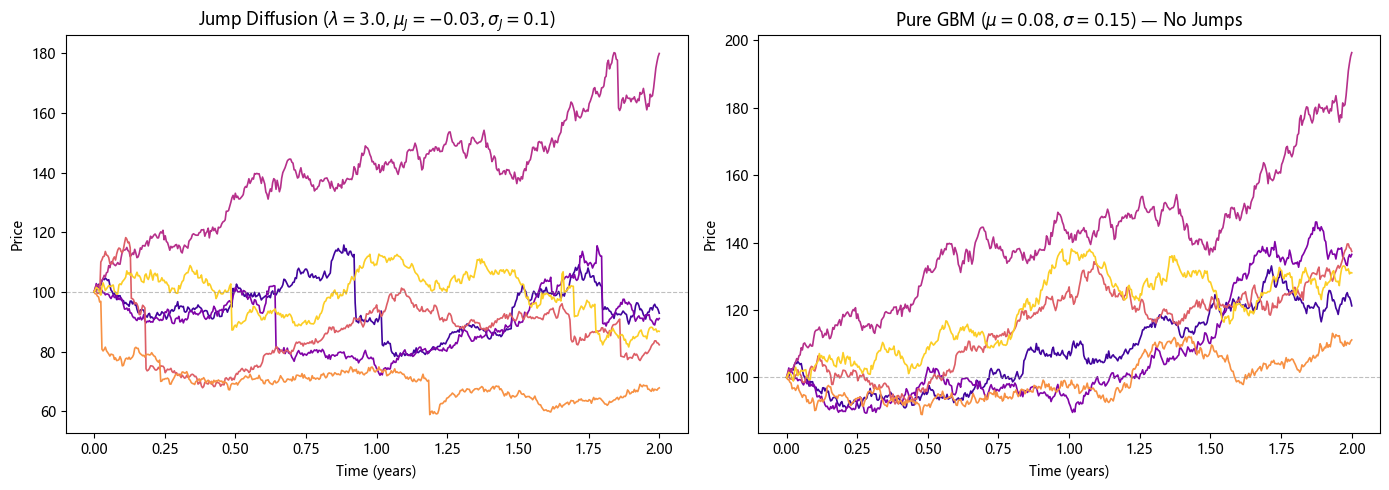

In [9]:
# ==========================================
# Jump Diffusion Process (Merton Model)
# ==========================================
# dS = mu*S*dt + sigma*S*dW + J*S*dN

np.random.seed(42)

# Parameters
S0 = 100          # initial price
mu = 0.08         # drift
sigma = 0.15      # diffusion volatility
T = 2.0           # 2 years
N = 500           # time steps
dt = T / N
n_paths = 6

# Jump parameters
jump_intensity = 3.0    # lambda: avg jumps per year
jump_mean = -0.03       # mu_J: mean log-jump size
jump_std = 0.10         # sigma_J: std of log-jump size

t = np.linspace(0, T, N + 1)

# Simulate
S = np.zeros((n_paths, N + 1))
S[:, 0] = S0

dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))

# Poisson jumps: number of jumps in each interval
jump_events = np.random.poisson(jump_intensity * dt, size=(n_paths, N))

for i in range(N):
    # Diffusion component
    diffusion = mu * dt + sigma * dW[:, i]
    # Jump component: sum of log-normal jumps
    jump_sizes = np.zeros(n_paths)
    for k in range(n_paths):
        if jump_events[k, i] > 0:
            jump_sizes[k] = np.random.normal(jump_mean, jump_std, jump_events[k, i]).sum()
    S[:, i + 1] = S[:, i] * np.exp(diffusion + jump_sizes)

# Comparison: pure GBM (no jumps) with same seed
np.random.seed(42)
S_gbm = np.zeros((n_paths, N + 1))
S_gbm[:, 0] = S0
dW2 = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
for i in range(N):
    S_gbm[:, i + 1] = S_gbm[:, i] * np.exp(mu * dt + sigma * dW2[:, i])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_paths))

for i in range(n_paths):
    axes[0].plot(t, S[i], linewidth=1.2, color=colors[i])
    axes[1].plot(t, S_gbm[i], linewidth=1.2, color=colors[i])

axes[0].set_title(f'Jump Diffusion ($\\lambda={jump_intensity}, \\mu_J={jump_mean}, \\sigma_J={jump_std}$)')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Price')
axes[0].axhline(S0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

axes[1].set_title(f'Pure GBM ($\\mu={mu}, \\sigma={sigma}$) — No Jumps')
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel('Price')
axes[1].axhline(S0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()



  Ridge 回归
5-Fold 交叉验证 RMSE: 24.2545 ± 1.6275
各折 RMSE: [22.9787 23.0993 26.1271 26.3529 22.7146]


c:\Users\hp\Desktop\Python_Projects\my_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.678e+04, tolerance: 4.228e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\hp\Desktop\Python_Projects\my_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.843e+05, tolerance: 4.203e+02
  model = cd_fast.enet_coordinate_descent(



  Lasso 回归
5-Fold 交叉验证 RMSE: 24.2670 ± 1.8022
各折 RMSE: [22.9469 22.8479 26.0764 26.8266 22.6369]


c:\Users\hp\Desktop\Python_Projects\my_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.461e+05, tolerance: 4.228e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\hp\Desktop\Python_Projects\my_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.766e+05, tolerance: 4.203e+02
  model = cd_fast.enet_coordinate_descent(



  ElasticNet 回归
5-Fold 交叉验证 RMSE: 24.3178 ± 1.7717
各折 RMSE: [22.9865 23.049  26.1623 26.7722 22.6189]

  OLS 基准 vs 正则化回归对比

OLS (多项式特征) 5-Fold CV RMSE: 24.2604
最佳模型: Ridge, RMSE = 24.2545
相对 OLS 提升: 0.02%

Ridge 最优参数: {'regressor__alpha': np.float64(0.0533669923120631)}

Ridge 特征系数 (Top 20):


,feature,coefficient,abs_coef
7,price competitor_price,130.989821,130.989821
6,price^2,-71.060751,71.060751
12,competitor_price^2,-59.778572,59.778572
19,ad_spend loyalty_score,52.772967,52.772967
17,ad_spend^2,-40.835909,40.835909
29,region_西部,-30.934413,30.934413
2,ad_spend,28.484598,28.484598
27,region_华北,-20.138992,20.138992
4,loyalty_score,15.418267,15.418267
10,price loyalty_score,-14.743151,14.743151



系数为零的特征数量: 0 / 32


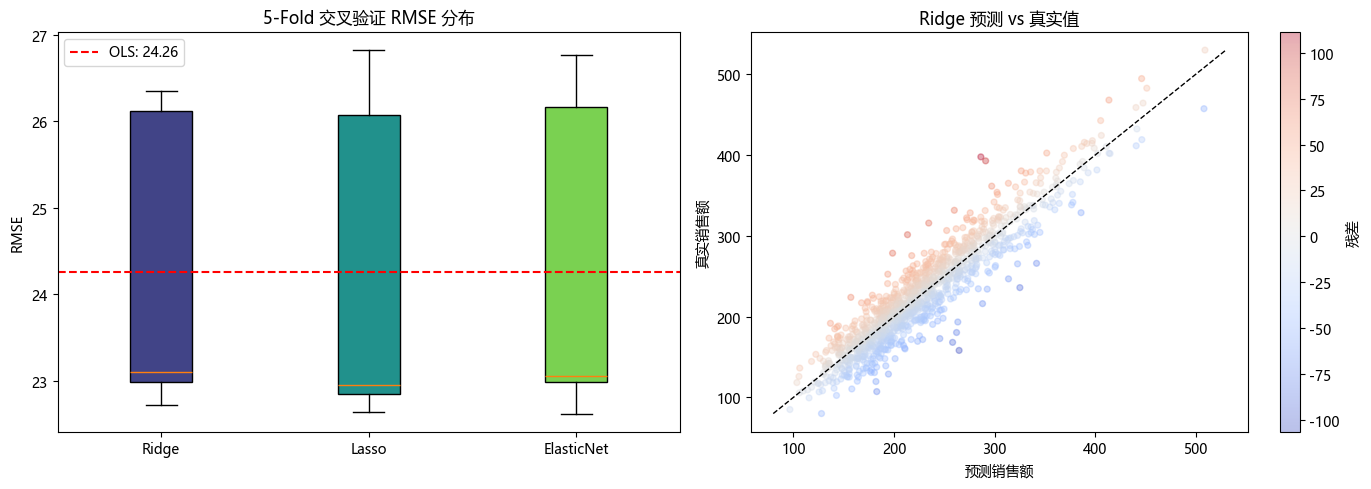


分析完成！


In [10]:
# ==========================================
# 极其复杂的回归分析：正则化回归 + 多项式特征 + 交叉验证
# ==========================================
# 比较 Ridge、Lasso、ElasticNet 三种正则化回归
# 使用 PolynomialFeatures、StandardScaler、GridSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler


def run_regularized_regression_analysis():
    """运行正则化回归对比分析，并返回关键结果。"""
    # 说明：
    # 1. 用更紧凑的参数网格减少搜索成本。
    # 2. 避免外层 CV 和内层 GridSearch 同时并行，降低进程争用。
    # 3. OLS 基准改为完整 pipeline，避免预处理泄漏。
    scoring = "neg_root_mean_squared_error"

    # ---- 0. 数据准备（复用前一个 cell 的数据生成逻辑）----
    rng = np.random.default_rng(2026)
    n = 1_200

    region = rng.choice(['华东', '华北', '华南', '西部'], size=n, p=[0.34, 0.26, 0.24, 0.16])
    channel = rng.choice(['线上', '线下', '混合'], size=n, p=[0.45, 0.35, 0.20])
    price = rng.lognormal(mean=4.15, sigma=0.32, size=n)
    ad_spend = rng.gamma(shape=2.4, scale=38, size=n)
    customer_age = np.clip(rng.normal(loc=36, scale=10, size=n), 18, 70)
    loyalty_score = rng.beta(a=2.2, b=4.0, size=n) * 100
    competitor_price = price * rng.normal(loc=1.04, scale=0.10, size=n)
    seasonality = np.sin(np.linspace(0, 6 * np.pi, n))

    region_effect = {'华东': 18, '华北': 5, '华南': 11, '西部': -7}
    channel_effect = {'线上': 16, '线下': -4, '混合': 9}
    noise_scale = 14 + 0.08 * ad_spend
    noise = rng.normal(loc=0, scale=noise_scale, size=n)

    sales = (
        120
        - 1.35 * price
        + 0.82 * competitor_price
        + 0.58 * ad_spend
        - 0.0026 * ad_spend**2
        + 0.72 * loyalty_score
        + 0.45 * customer_age
        + 0.018 * ad_spend * loyalty_score
        + 12 * seasonality
        + np.array([region_effect[x] for x in region])
        + np.array([channel_effect[x] for x in channel])
        + np.where((region == '华东') & (channel == '线上'), 14, 0)
        + noise
    )

    reg_df = pd.DataFrame({
        'sales': sales,
        'price': price,
        'competitor_price': competitor_price,
        'ad_spend': ad_spend,
        'customer_age': customer_age,
        'loyalty_score': loyalty_score,
        'seasonality': seasonality,
        'region': region,
        'channel': channel,
    })

    for col in ['price', 'ad_spend', 'loyalty_score']:
        missing_mask = rng.random(n) < 0.025
        reg_df.loc[missing_mask, col] = np.nan

    model_df = reg_df.copy()
    numeric_cols = ['price', 'competitor_price', 'ad_spend', 'customer_age', 'loyalty_score', 'seasonality']
    for col in numeric_cols:
        model_df[col] = model_df[col].fillna(model_df[col].median())

    # ---- 1. 准备特征矩阵和目标变量 ----
    X = model_df.drop(columns=["sales"])
    y = model_df["sales"]

    # 区分数值列和类别列
    num_cols = [
        "price",
        "competitor_price",
        "ad_spend",
        "customer_age",
        "loyalty_score",
        "seasonality",
    ]
    cat_cols = ["region", "channel"]

    # ---- 2. 构建复杂的预处理流水线 ----
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        (
                            "poly",
                            PolynomialFeatures(
                                degree=2, include_bias=False, interaction_only=False
                            ),
                        ),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
        ]
    )

    # ---- 3. 定义多种模型和参数网格 ----
    models_and_params = {
        "Ridge": (
            Ridge(max_iter=3000),
            {
                "regressor__alpha": np.logspace(-2, 2, 12),
            },
        ),
        "Lasso": (
            Lasso(max_iter=3000, random_state=42),
            {
                "regressor__alpha": np.logspace(-3, 1, 12),
            },
        ),
        "ElasticNet": (
            ElasticNet(max_iter=3000, random_state=42),
            {
                "regressor__alpha": np.logspace(-3, 1, 8),
                "regressor__l1_ratio": np.linspace(0.2, 0.8, 4),
            },
        ),
    }

    # ---- 4. 交叉验证比较 ----
    outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
    inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

    results = {}

    for name, (estimator, param_grid) in models_and_params.items():
        pipe = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("regressor", estimator),
            ]
        )

        grid = GridSearchCV(
            pipe,
            param_grid,
            cv=inner_cv,
            scoring=scoring,
            n_jobs=-1,
            verbose=0,
        )

        cv_scores = cross_val_score(
            grid,
            X,
            y,
            cv=outer_cv,
            scoring=scoring,
            n_jobs=1,
            verbose=0,
        )

        fold_rmse = -cv_scores
        results[name] = {
            "cv_rmse": fold_rmse,
            "cv_rmse_mean": fold_rmse.mean(),
            "cv_rmse_std": fold_rmse.std(),
        }

        print(f"\n{'=' * 50}")
        print(f"  {name} 回归")
        print(f"{'=' * 50}")
        print(
            f"5-Fold 交叉验证 RMSE: {results[name]['cv_rmse_mean']:.4f} ± {results[name]['cv_rmse_std']:.4f}"
        )
        print(f"各折 RMSE: {np.round(results[name]['cv_rmse'], 4)}")

    # ---- 5. 全量数据上找最优参数并展示 ----
    print(f"\n{'=' * 50}")
    print("  OLS 基准 vs 正则化回归对比")
    print(f"{'=' * 50}")

    # OLS 基准：使用完整 pipeline，避免预处理泄漏
    ols_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", LinearRegression()),
        ]
    )
    ols_cv = cross_val_score(
        ols_pipe, X, y, cv=outer_cv, scoring=scoring, n_jobs=1
    )
    ols_rmse = (-ols_cv).mean()

    print(f"\nOLS (多项式特征) 5-Fold CV RMSE: {ols_rmse:.4f}")

    best_model_name = min(results, key=lambda k: results[k]["cv_rmse_mean"])
    best_rmse = results[best_model_name]["cv_rmse_mean"]

    print(f"最佳模型: {best_model_name}, RMSE = {best_rmse:.4f}")
    print(f"相对 OLS 提升: {(ols_rmse - best_rmse) / ols_rmse * 100:.2f}%")

    # ---- 6. 最终模型：全量数据拟合 + 特征重要性 ----
    best_estimator, best_param_grid = models_and_params[best_model_name]
    final_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", best_estimator),
        ]
    )

    final_grid = GridSearchCV(
        final_pipe,
        best_param_grid,
        cv=inner_cv,
        scoring=scoring,
        n_jobs=-1,
    )
    final_grid.fit(X, y)

    print(f"\n{best_model_name} 最优参数: {final_grid.best_params_}")

    # 特征名称提取
    num_feature_names = (
        PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
        .fit(model_df[num_cols])
        .get_feature_names_out(num_cols)
    )
    cat_feature_names = (
        OneHotEncoder(drop="first", sparse_output=False)
        .fit(model_df[cat_cols])
        .get_feature_names_out(cat_cols)
    )
    all_feature_names = list(num_feature_names) + list(cat_feature_names)

    # 系数
    if best_model_name in ("Ridge", "Lasso", "ElasticNet"):
        coefs = final_grid.best_estimator_.named_steps["regressor"].coef_
        coef_df = (
            pd.DataFrame(
                {
                    "feature": all_feature_names,
                    "coefficient": coefs,
                }
            )
            .assign(abs_coef=lambda df: df["coefficient"].abs())
            .sort_values("abs_coef", ascending=False)
        )

        print(f"\n{best_model_name} 特征系数 (Top 20):")
        display(coef_df.head(20))

        # 零系数的特征数量 (Lasso / ElasticNet 特有)
        zero_count = (np.abs(coefs) < 1e-8).sum()
        print(f"\n系数为零的特征数量: {zero_count} / {len(coefs)}")

    # ---- 7. 可视化：模型对比 ----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 左图：各模型 RMSE 箱线图
    model_names = list(results.keys())
    rmse_data = [results[m]["cv_rmse"] for m in model_names]
    bp = axes[0].boxplot(rmse_data, tick_labels=model_names, patch_artist=True)
    for patch, color in zip(
        bp["boxes"], plt.cm.viridis(np.linspace(0.2, 0.8, len(model_names)))
    ):
        patch.set_facecolor(color)
    axes[0].set_title("5-Fold 交叉验证 RMSE 分布")
    axes[0].set_ylabel("RMSE")
    axes[0].axhline(
        ols_rmse, color="red", linestyle="--", linewidth=1.5, label=f"OLS: {ols_rmse:.2f}"
    )
    axes[0].legend()

    # 右图：最优模型预测 vs 真实值
    y_pred_best = final_grid.predict(X)
    residuals_best = y.values - y_pred_best
    axes[1].scatter(
        y_pred_best, y.values, alpha=0.35, s=18, c=residuals_best, cmap="coolwarm"
    )
    line_min = min(y_pred_best.min(), y.values.min())
    line_max = max(y_pred_best.max(), y.values.max())
    axes[1].plot([line_min, line_max], [line_min, line_max], "k--", linewidth=1)
    axes[1].set_title(f"{best_model_name} 预测 vs 真实值")
    axes[1].set_xlabel("预测销售额")
    axes[1].set_ylabel("真实销售额")
    cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
    cbar.set_label("残差")

    plt.tight_layout()
    plt.show()

    print("\n分析完成！")

    return {
        "results": results,
        "ols_rmse": ols_rmse,
        "best_model_name": best_model_name,
        "best_rmse": best_rmse,
        "final_grid": final_grid,
        "all_feature_names": all_feature_names,
    }


analysis_result = run_regularized_regression_analysis()


  集成学习 vs 正则化回归 对比分析

模型交叉验证 RMSE 对比:
--------------------------------------------------
  Ridge           | RMSE = 24.3255 ± 1.7235
  Lasso           | RMSE = 26.0085 ± 1.8774
  ElasticNet      | RMSE = 33.3171 ± 1.9964
  GBRT            | RMSE = 26.4448 ± 1.3599
  RandomForest    | RMSE = 29.3972 ± 1.0499

最优模型: Ridge, RMSE = 24.3255
OLS (多项式特征) 基准 RMSE: 24.2587
相对 OLS 提升: -0.28%


C:\Users\hp\AppData\Local\Temp\ipykernel_14768\491098542.py:216: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(rmse_data, labels=names, patch_artist=True)


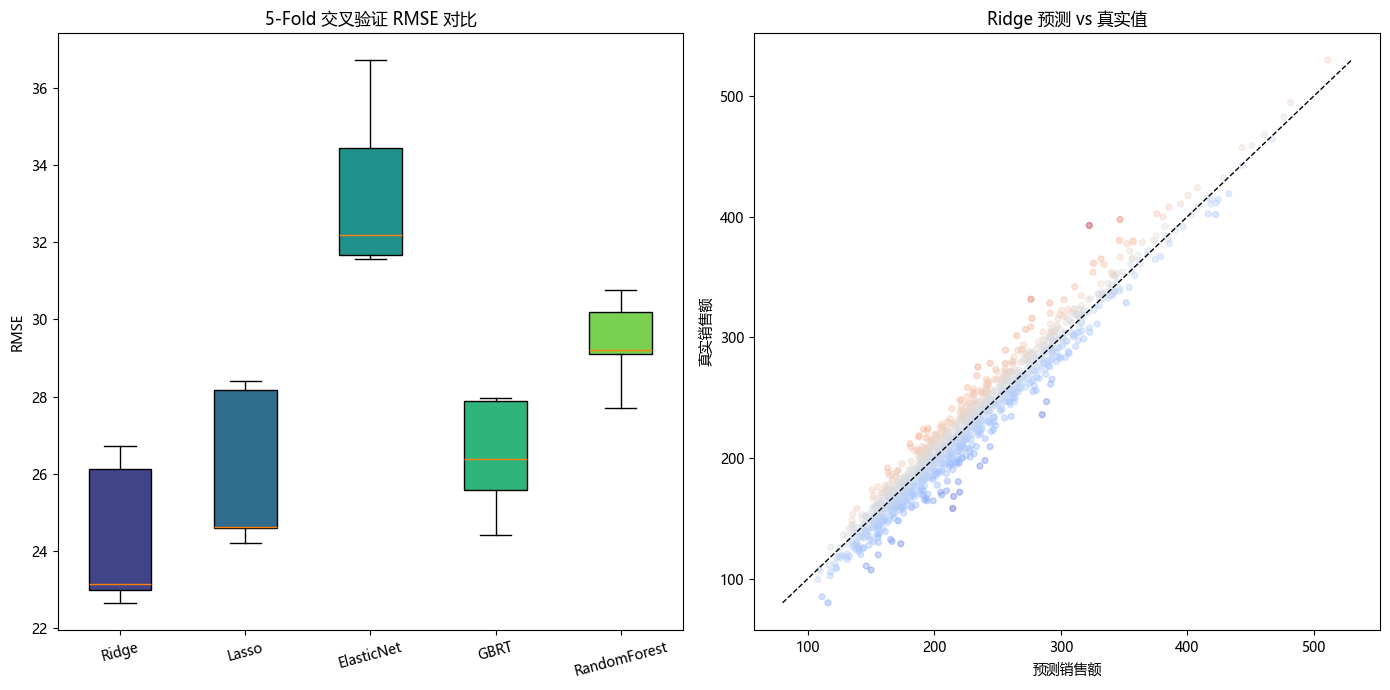

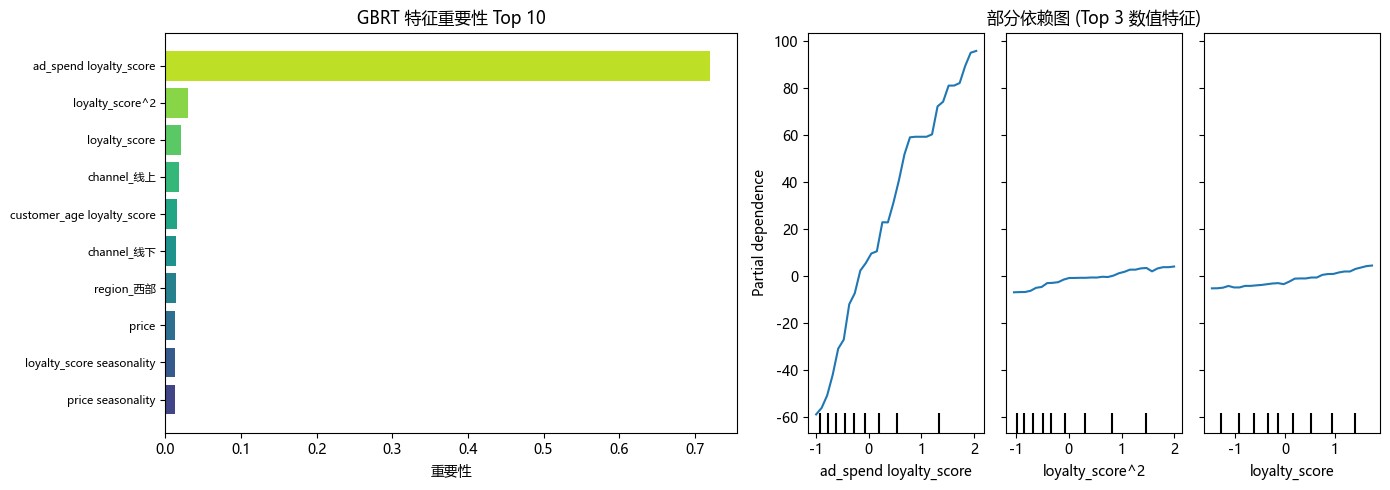


GBRT 特征重要性 Top 15:


,feature,importance
19,ad_spend loyalty_score,0.720162
24,loyalty_score^2,0.029965
4,loyalty_score,0.020988
30,channel_线上,0.017623
22,customer_age loyalty_score,0.015541
31,channel_线下,0.014524
29,region_西部,0.014053
0,price,0.013056
25,loyalty_score seasonality,0.012530
11,price seasonality,0.012422



分析完成！


In [13]:
# ==========================================
# 集成学习 vs 正则化回归：Gradient Boosting 对比
# ==========================================
# 使用 sklearn GradientBoostingRegressor 与之前的最优正则化模型对比
# 展示树模型的特征重要性、部分依赖图（PDP）和 SHAP 值

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer # noqa: F811
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge # noqa: F811
from sklearn.model_selection import KFold, cross_val_score # noqa: F811
from sklearn.pipeline import Pipeline # noqa: F811
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler # noqa: F811

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False


# ---- 0. 数据准备 ----
def prepare_data(seed=2026, n_samples=1200):
    """生成与前面 cell 一致的模拟数据，包含非线性项、交互项和类别变量。"""
    rng = np.random.default_rng(seed)

    region = rng.choice(
        ["华东", "华北", "华南", "西部"], size=n_samples, p=[0.34, 0.26, 0.24, 0.16]
    )
    channel = rng.choice(["线上", "线下", "混合"], size=n_samples, p=[0.45, 0.35, 0.20])
    price = rng.lognormal(mean=4.15, sigma=0.32, size=n_samples)
    ad_spend = rng.gamma(shape=2.4, scale=38, size=n_samples)
    customer_age = np.clip(rng.normal(loc=36, scale=10, size=n_samples), 18, 70)
    loyalty_score = rng.beta(a=2.2, b=4.0, size=n_samples) * 100
    competitor_price = price * rng.normal(loc=1.04, scale=0.10, size=n_samples)
    seasonality = np.sin(np.linspace(0, 6 * np.pi, n_samples))

    region_effect = {"华东": 18, "华北": 5, "华南": 11, "西部": -7}
    channel_effect = {"线上": 16, "线下": -4, "混合": 9}
    noise_scale = 14 + 0.08 * ad_spend
    noise = rng.normal(loc=0, scale=noise_scale, size=n_samples)

    sales = (
        120
        - 1.35 * price
        + 0.82 * competitor_price
        + 0.58 * ad_spend
        - 0.0026 * ad_spend**2
        + 0.72 * loyalty_score
        + 0.45 * customer_age
        + 0.018 * ad_spend * loyalty_score
        + 12 * seasonality
        + np.array([region_effect[x] for x in region])
        + np.array([channel_effect[x] for x in channel])
        + np.where((region == "华东") & (channel == "线上"), 14, 0)
        + noise
    )

    df = pd.DataFrame(
        {
            "sales": sales,
            "price": price,
            "competitor_price": competitor_price,
            "ad_spend": ad_spend,
            "customer_age": customer_age,
            "loyalty_score": loyalty_score,
            "seasonality": seasonality,
            "region": region,
            "channel": channel,
        }
    )

    for col in ["price", "ad_spend", "loyalty_score"]:
        df.loc[rng.random(n_samples) < 0.025, col] = np.nan

    for col in [
        "price",
        "competitor_price",
        "ad_spend",
        "customer_age",
        "loyalty_score",
        "seasonality",
    ]:
        df[col] = df[col].fillna(df[col].median())

    return df


# ---- 1. 构建预处理流水线 ----
def build_preprocessor(num_cols, cat_cols, for_tree=False):
    """
    构建 ColumnTransformer。
    for_tree=True 时：数值列仅做 OneHot（树模型不需要多项式扩展和标准化）。
    for_tree=False 时：数值列做多项式 + 标准化（线性模型需要）。
    """
    if for_tree:
        return ColumnTransformer(
            transformers=[
                ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
            ],
            remainder="passthrough",
        )
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            ),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
        ]
    )


# ---- 2. 交叉验证评估 ----
def evaluate_models(X, y, preprocessor, num_cols, cat_cols, cv_outer=5):
    """使用嵌套交叉验证评估 Ridge / Lasso / ElasticNet / GBRT / RandomForest。"""

    tree_prep = build_preprocessor(num_cols, cat_cols, for_tree=True)

    models = {
        "Ridge": Pipeline(
            steps=[
                ("prep", preprocessor),
                ("model", Ridge(max_iter=5000)),
            ]
        ),
        "Lasso": Pipeline(
            steps=[
                ("prep", preprocessor),
                ("model", Lasso(max_iter=5000, random_state=42)),
            ]
        ),
        "ElasticNet": Pipeline(
            steps=[
                ("prep", preprocessor),
                ("model", ElasticNet(max_iter=5000, random_state=42)),
            ]
        ),
        "GBRT": Pipeline(
            steps=[
                ("prep", tree_prep),
                (
                    "model",
                    GradientBoostingRegressor(
                        n_estimators=300,
                        learning_rate=0.05,
                        max_depth=4,
                        min_samples_leaf=10,
                        subsample=0.8,
                        random_state=42,
                    ),
                ),
            ]
        ),
        "RandomForest": Pipeline(
            steps=[
                ("prep", tree_prep),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=300,
                        max_depth=10,
                        min_samples_leaf=5,
                        random_state=42,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
    }

    results = {}
    outer_cv = KFold(n_splits=cv_outer, shuffle=True, random_state=42)

    for name, pipe in models.items():
        cv_scores = cross_val_score(
            pipe,
            X,
            y,
            cv=outer_cv,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            verbose=0,
        )
        rmse_scores = np.sqrt(-cv_scores)
        results[name] = {
            "rmse_mean": rmse_scores.mean(),
            "rmse_std": rmse_scores.std(),
            "rmse_folds": rmse_scores,
        }
        print(
            f"  {name:15s} | RMSE = {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}"
        )

    return results


# ---- 3. 可视化对比 ----
def plot_model_comparison(results, X, y, preprocessor, best_name):
    """绘制模型 RMSE 对比图 + 最优模型预测 vs 真实值散点图。"""

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # 左图：RMSE 箱线图
    names = list(results.keys())
    rmse_data = [results[n]["rmse_folds"] for n in names]
    bp = axes[0].boxplot(rmse_data, labels=names, patch_artist=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    axes[0].set_title("5-Fold 交叉验证 RMSE 对比")
    axes[0].set_ylabel("RMSE")
    axes[0].tick_params(axis="x", rotation=15)

    # 右图：最优模型预测 vs 真实值
    best_pipe = Pipeline(
        steps=[
            ("prep", preprocessor),
            (
                "model",
                GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=4,
                    min_samples_leaf=10,
                    subsample=0.8,
                    random_state=42,
                ),
            ),
        ]
    )
    best_pipe.fit(X, y)
    y_pred = best_pipe.predict(X)

    axes[1].scatter(y_pred, y, alpha=0.35, s=18, c=y - y_pred, cmap="coolwarm")
    lo, hi = min(y_pred.min(), y.min()), max(y_pred.max(), y.max())
    axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1)
    axes[1].set_title(f"{best_name} 预测 vs 真实值")
    axes[1].set_xlabel("预测销售额")
    axes[1].set_ylabel("真实销售额")

    plt.tight_layout()
    plt.show()

    return best_pipe


# ---- 4. 特征重要性 + 部分依赖图 ----
def plot_feature_importance(model, preprocessor, X, num_cols, cat_cols):
    """展示 GBRT 的特征重要性和 Top 3 特征的部分依赖图。"""

    # 特征名称
    num_feat_names = (
        PolynomialFeatures(degree=2, include_bias=False)
        .fit(X[num_cols])
        .get_feature_names_out(num_cols)
    )
    cat_feat_names = (
        OneHotEncoder(drop="first", sparse_output=False)
        .fit(X[cat_cols])
        .get_feature_names_out(cat_cols)
    )
    all_names = list(num_feat_names) + list(cat_feat_names)

    gbrt = model.named_steps["model"]
    importance = pd.DataFrame(
        {
            "feature": all_names,
            "importance": gbrt.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 左图：Top 15 特征重要性
    top15 = importance.head(10)
    axes[0].barh(
        range(len(top15)),
        top15["importance"].values[::-1],
        color=plt.cm.viridis(np.linspace(0.2, 0.9, 10)),
    )
    axes[0].set_yticks(range(len(top15)))
    axes[0].set_yticklabels(top15["feature"].values[::-1], fontsize=8)
    axes[0].set_title("GBRT 特征重要性 Top 10")
    axes[0].set_xlabel("重要性")

    # 右图：对 Top 3 数值特征的部分依赖图
    top3_num = [f for f in top15["feature"].values if f in num_feat_names][:3]
    if top3_num:
        top3_idx = [list(all_names).index(f) for f in top3_num]
        X_processed = preprocessor.transform(X)
        PartialDependenceDisplay.from_estimator(
            gbrt,
            X_processed,
            features=top3_idx,
            feature_names=all_names,
            ax=axes[1],
            grid_resolution=30,
        )
        axes[1].set_title("部分依赖图 (Top 3 数值特征)")

    plt.tight_layout()
    plt.show()

    print("\nGBRT 特征重要性 Top 15:")
    display(top15)


# ---- 5. 主流程 ----
def main():
    """主流程：数据准备 → 模型评估 → 可视化对比 → 特征重要性分析。"""

    print("=" * 50)
    print("  集成学习 vs 正则化回归 对比分析")
    print("=" * 50)

    # 准备数据
    df = prepare_data()
    num_cols = [
        "price",
        "competitor_price",
        "ad_spend",
        "customer_age",
        "loyalty_score",
        "seasonality",
    ]
    cat_cols = ["region", "channel"]
    X = df.drop(columns=["sales"])
    y = df["sales"]

    preprocessor = build_preprocessor(num_cols, cat_cols)

    # 交叉验证评估
    print("\n模型交叉验证 RMSE 对比:")
    print("-" * 50)
    results = evaluate_models(X, y, preprocessor, num_cols, cat_cols)

    # 找出最优模型
    best_name = min(results, key=lambda k: results[k]["rmse_mean"])
    best_rmse = results[best_name]["rmse_mean"]
    print(f"\n最优模型: {best_name}, RMSE = {best_rmse:.4f}")

    # 与 OLS 基准对比
    ols_pipe = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("model", LinearRegression()),
        ]
    )
    ols_cv = cross_val_score(ols_pipe, X, y, cv=5, scoring="neg_mean_squared_error")
    ols_rmse = np.sqrt(-ols_cv.mean())
    print(f"OLS (多项式特征) 基准 RMSE: {ols_rmse:.4f}")
    print(f"相对 OLS 提升: {(ols_rmse - best_rmse) / ols_rmse * 100:.2f}%")

    # 可视化
    best_pipe = plot_model_comparison(results, X, y, preprocessor, best_name)

    # 特征重要性
    plot_feature_importance(best_pipe, preprocessor, X, num_cols, cat_cols)

    print("\n分析完成！")


main()




